In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import fisher_exact
import scanpy as sc
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# ------------------------------------------------------------------
# 1) Load gene sets
# ------------------------------------------------------------------
# Adjust these paths/filenames if you changed the notebook outputs
region       = "Isocortex-1"          # same variable you used earlier
base_path    = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630")

In [ ]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

In [12]:
def fisher_enrichment(set_a, set_b, gene_universe):
    """
    One-sided Fisher exact test (greater) for overlap of two gene sets.
    Returns p-value, odds ratio, overlap size.
    """
    k   = len(set_a & set_b)                        # overlap
    a   = len(set_a) - k                            # only in A
    b   = len(set_b) - k                            # only in B
    c   = len(gene_universe) - (k + a + b)          # in neither
    odds, p = fisher_exact([[k, a], [b, c]], alternative='greater')
    return p, odds, k

In [28]:
# 1a. CNA modules (CSV produced by hdWGCNA section)
modules_df   = pd.read_csv(base_path / f"outputs/WMB-10Xv3-{region}-raw-mc-wgcna-modules.csv",
                           index_col=0)

# Keep only module label + gene column (rename if yours differ)
modules_df = modules_df[["module", "gene_name"]]

# Build gene ID → symbol mapping from adata
id_to_symbol = adata.var["gene_symbol"].to_dict()

# Convert gene IDs to symbols
modules_df["gene_symbol"] = modules_df["gene_name"].map(id_to_symbol)

# Drop any rows where symbol is missing (unmapped genes)
modules_df = modules_df.dropna(subset=["gene_symbol"])

# Build dict: module -> set of genes
modules_dict = (modules_df
                .groupby("module")["gene_symbol"]
                .agg(set)
                .to_dict())

In [63]:
# 1b. DEGs (CSV produced by DEA notebook)
deg_path     = base_path / "outputs/DEG" / f"WMB-10Xv3-{region}-DEG-class.csv"
deg_results  = pd.read_csv(deg_path)

# Each column is ranked DEGs for one cluster; convert to list then set
deg_sets = dict()
for cluster in deg_results.columns:
    genes = deg_results[cluster].dropna().astype(str).tolist()
    deg_sets[cluster] = genes  # <- ordered list

# 1c. Define gene universe (all genes that passed QC and were tested)
gene_universe = set(modules_df["gene_name"]).union(*deg_sets.values())

print(f"{len(modules_dict)} modules · {len(deg_sets)} DEG sets · "
      f"{len(gene_universe)} genes in universe")

9 modules · 10 DEG sets · 3438 genes in universe


In [ ]:
# ------------------------------------------------------------------
# 2) Enrichment statistics matrix (with deg_sets as ordered lists)
# ------------------------------------------------------------------
index  = sorted(modules_dict)     # rows = CNA modules
cols   = sorted(deg_sets)         # cols = DEG clusters

p_mat       = pd.DataFrame(np.nan, index=index, columns=cols)
odds_mat    = p_mat.copy()
jaccard_mat = p_mat.copy()
k_mat       = p_mat.copy()

top_n = 200  # or whatever threshold you want

for mod in index:
    mod_genes = modules_dict[mod]  # already a set
    for clust in cols:
        top_deg_genes = set(deg_sets[clust][:top_n])  # preserve order, then convert to set

        p, odds, k = fisher_enrichment(mod_genes, top_deg_genes, gene_universe)
        jaccard    = k / (len(mod_genes) + len(top_deg_genes) - k) if (len(mod_genes) + len(top_deg_genes) - k) > 0 else 0

        p_mat.loc[mod, clust]        = p
        odds_mat.loc[mod, clust]     = odds
        jaccard_mat.loc[mod, clust]  = jaccard
        k_mat.loc[mod, clust]        = k

# Benjamini–Hochberg FDR correction
p_adj = pd.DataFrame(
    multipletests(p_mat.values.flatten(), method="fdr_bh")[1]
    .reshape(p_mat.shape),
    index=index, columns=cols
)

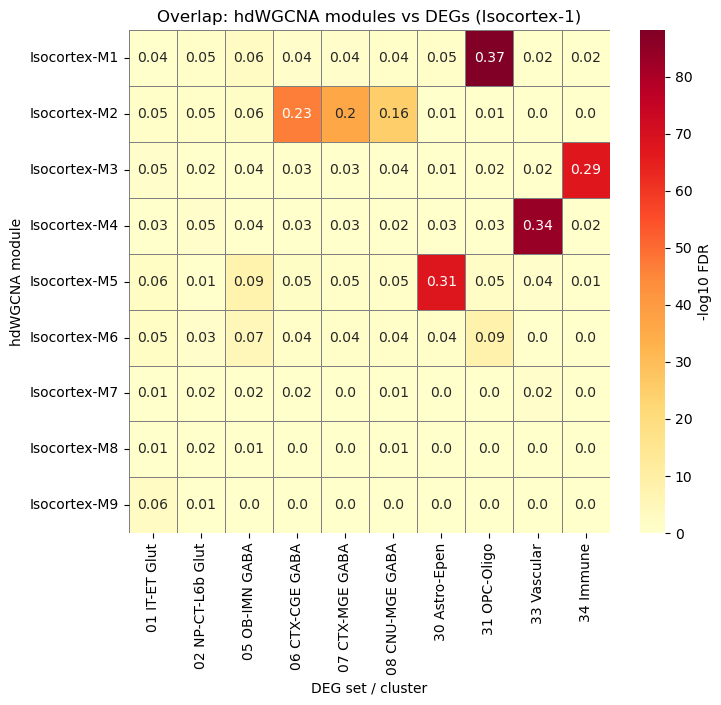

In [77]:
# ------------------------------------------------------------------
# 3) Heat-map of –log10(FDR) with Jaccard annotation
# ------------------------------------------------------------------
log_fdr = -np.log10(p_adj.clip(lower=1e-300))   # avoid log(0)

plt.figure(figsize=(0.35*len(cols)+4, 0.35*len(index)+4))
ax = sns.heatmap(log_fdr,
                 cmap="YlOrRd",
                 linewidths=.5,
                 linecolor='grey',
                 annot=jaccard_mat.round(2),
                 fmt="",
                 cbar_kws={"label": "-log10 FDR"})
ax.set_title(f"Overlap: hdWGCNA modules vs DEGs ({region})")
ax.set_xlabel("DEG set / cluster")
ax.set_ylabel("hdWGCNA module")
plt.tight_layout()
plt.show()